# Homework (Week 3) -- Biometrics (20 points)

In this homework we train Biometrics Verification model and use some features to increase quality:
1) Train ECAPA-TDNN (10 points)
2) Any contrastive loss (10 points)

Link to download dataset: https://disk.yandex.ru/d/lyhtieYbxQOYqw

In [1]:
!wget https://raw.githubusercontent.com/crustaceano/speech_course/refs/heads/main/week_03_kws_bio/dataset.py -O dataset.py

--2026-03-22 17:19:53--  https://raw.githubusercontent.com/crustaceano/speech_course/refs/heads/main/week_03_kws_bio/dataset.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1531 (1.5K) [text/plain]
Saving to: ‘dataset.py’

dataset.py          100%[===================>]   1.50K  --.-KB/s    in 0s      

2026-03-22 17:19:53 (54.3 MB/s) - ‘dataset.py’ saved [1531/1531]



In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as torch_data
import torchaudio
import tqdm.notebook as tqdm
import urllib

import dataset

from IPython.display import clear_output

%matplotlib inline

In [3]:
base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/lyhtieYbxQOYqw'
final_url = base_url + urllib.parse.urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']
!wget -O voxceleb.tar.gz "{download_url}"
!tar -xf voxceleb.tar.gz

--2026-03-22 17:19:58--  https://downloader.disk.yandex.ru/disk/76545cc5e161a260d9a4705290a34868ecce1bd32f926fd3ad704bb66ecde4ef/69c05cfe/gtj3WQiuHGabqHv6W0pVHGRnXFJAW27izLLMm2MbHXViekKTxmGtGgT-Cdced2Nyo5eSrwwUCF_GbUu7CV3RNA%3D%3D?uid=0&filename=voxceleb.tar.gz&disposition=attachment&hash=UbepA8Q9HDxeFKWCa8Y0tO7K9asCmTAjTZtG1dex6z7oEbCbmS7yu53hGphcr8rhq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=application%2Fx-gzip&owner_uid=163052607&fsize=7150565898&hid=d5bd9cc88bda4eba5b285b6d33a11c38&media_type=compressed&tknv=v3
Resolving downloader.disk.yandex.ru (downloader.disk.yandex.ru)... 77.88.21.127, 2a02:6b8::2:127
Connecting to downloader.disk.yandex.ru (downloader.disk.yandex.ru)|77.88.21.127|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://s1144sas.storage.yandex.net/rdisk/76545cc5e161a260d9a4705290a34868ecce1bd32f926fd3ad704bb66ecde4ef/69c05cfe/gtj3WQiuHGabqHv6W0pVHGRnXFJAW27izLLMm2MbHXViekKTxmGtGgT-Cdced2Nyo5eSrwwUCF_GbUu7CV3RNA==?uid=0&

### Some model train example

In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DATADIR = '.'
FEATS = 80
LOADER_WORKERS = 8

In [5]:
train_transform = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_mels=FEATS),
    torchaudio.transforms.AmplitudeToDB(),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=12),
    torchaudio.transforms.TimeMasking(time_mask_param=15),
)
trainset = dataset.Dataset(os.path.join(DATADIR, 'voxceleb_train'), train_transform)

test_transform = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_mels=FEATS),
    torchaudio.transforms.AmplitudeToDB(),
)
testset = dataset.Dataset(os.path.join(DATADIR, 'voxceleb_test'), test_transform)

test_targets = pd.read_csv(os.path.join(DATADIR, 'target.csv')).values.tolist()

### Models

In [ ]:
class Model(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, hidden: int, kernel: int = 7, sride: int = 2):
        super().__init__()
        self._emb = nn.Sequential(
            nn.Conv1d(input_shape, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel, stride=sride),
            nn.AdaptiveMaxPool1d(1),
        )
        self._final = nn.Sequential(
            nn.Linear(hidden, output_shape),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, X) -> tuple[torch.Tensor, torch.Tensor]:
        emb = self._emb(X).squeeze(2)
        return self._final(emb), emb

### Metrics

Cosine similarity:
$CS(a, b) = \frac{<a, b>}{\|a\| \|b\|}$

In [6]:
def cosine_similarity(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    return np.dot(a, b) / np.linalg.norm(a) / np.linalg.norm(b)

Here is O(N log N) algorithm for find best_eer:
1) Sort prediction by probability
2) Going through items and recalculating far and frr

In [7]:
def best_eer(data):
    full = sorted(data, key=lambda x: (x[0], -x[1]))
    pos = len([item for item in full if item[1] == 1])
    neg = len(full) - pos
    cur_pos = pos
    cur_neg = 0
    best_eer = 1
    for _, label in full:
        if label == 1:
            cur_pos -= 1
        else:
            cur_neg += 1
        cur_eer = max((pos - cur_pos) / pos, (neg - cur_neg) / neg)
        best_eer = min(best_eer, cur_eer)
    return best_eer

### Train

In [8]:
def train_stage(model, opt, batch_size: int = 256, scheduler=None):
    loader = torch_data.DataLoader(
        trainset,
        shuffle=True,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    loss_sum = 0.0
    batches = 0
    for X, Y, _ in tqdm.tqdm(loader):
        logits, _ = model.forward(X.to(DEVICE))
        loss = F.nll_loss(logits, Y.to(DEVICE))
        loss_sum += loss.item()
        batches += 1
        opt.zero_grad()
        loss.backward()
        opt.step()
    if scheduler is not None:
        scheduler.step()
    return loss_sum / batches

In [9]:
def calc_eval_score(model: nn.Module, batch_size: int = 256):
    loader = torch_data.DataLoader(
        testset,
        batch_size=batch_size,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
    )
    items = {}
    target_scores = []
    with torch.no_grad():
        for X, _, pathes in tqdm.tqdm(loader):
            _, embds = model.forward(X.to(DEVICE))
            embds = embds.cpu().data.numpy().reshape(X.shape[0], -1)
            for embd, path in zip(embds, pathes):
                items[path] = embd
    for item1, item2, target in test_targets:
        target_scores.append((cosine_similarity(items[item1], items[item2]), target))
    return best_eer(target_scores)

In [10]:
def train(
    model: nn.Module,
    opt,
    batch_size: int = 256,
    epochs: int = 10,
    train_fun = train_stage,
    train_kwargs = {},
):
    train_losses = []
    eval_scores = []
    for epoch in range(epochs):
        model.train()
        train_losses.append(train_fun(model, opt, batch_size=batch_size, **train_kwargs))
        model.eval()
        eval_scores.append(calc_eval_score(model, batch_size=batch_size))
        clear_output()
        fig, axis = plt.subplots(1, 2, figsize=(15, 7))
        axis[0].plot(np.arange(1, epoch + 2), train_losses, label='train CE loss')
        axis[1].plot(np.arange(1, epoch + 2), eval_scores, label='eval')
        axis[0].set(xlabel='epoch', ylabel='CE Loss')
        axis[1].set(xlabel='epoch', ylabel='EER')
        fig.legend()
        plt.show()
        print(f'Epoch {epoch + 1}. Train loss {train_losses[-1]}. Eval score {eval_scores[-1]}')

In [11]:
# model = Model(FEATS, trainset.speakers(), 128).to(DEVICE)
# opt = optim.Adam(model.parameters())
# train(model, opt)

### ECAPA TDNN (10 points)

Paper: https://arxiv.org/pdf/2005.07143.pdf

Papers for ECAPA parts:
- SE-Blocks - https://arxiv.org/pdf/1709.01507.pdf
- Res2Net - https://arxiv.org/pdf/1904.01169.pdf
- Attentive Stats Pooling - https://arxiv.org/pdf/1803.10963.pdf
- AAM Softmax - https://arxiv.org/pdf/1906.07317.pdf

Also you can optionally add other settings for paper:
- SpecAug
- Weight decay for optimizer
- LR scheduler

In [12]:
input2d = torch.randn(16, 80, 28, 28)
input1d = torch.randn(16, 80, 400)

In [13]:
class SEBlock1d(nn.Module):
    def __init__(self, in_channels, reduction: int = 128):
        super().__init__()

        self.global_pooling = nn.AdaptiveAvgPool1d(1)
        self.se = nn.Sequential(
            nn.Linear(in_channels, reduction),
            nn.ReLU(),
            nn.Linear(reduction, in_channels),
            nn.Sigmoid(),
        )



    def __call__(self, X):
        poooled_X = self.global_pooling(X).squeeze()
        weights = self.se(poooled_X).unsqueeze(-1)
        return weights * X

class SEBlock2d(nn.Module):
    def __init__(self, in_channels, reduction: int = 16):
        super().__init__()

        self.global_pooling = nn.AdaptiveAvgPool2d(1)
        self.se = nn.Sequential(
            nn.Linear(in_channels, reduction),
            nn.ReLU(),
            nn.Linear(reduction, in_channels),
            nn.Sigmoid(),
        )



    def __call__(self, X):
        poooled_X = self.global_pooling(X).squeeze()
        weights = self.se(poooled_X).unsqueeze(-1).unsqueeze(-1)
        return weights * X

In [14]:
se_block = SEBlock2d(80, 16)
output = se_block(input2d)
coeff = output[:, :, 0, 0] / input2d[:, :, 0, 0]
assert output.shape == input2d.shape
assert torch.all(abs((input2d * coeff.unsqueeze(-1).unsqueeze(-1)) - output) < 1e-6)

In [15]:
class Res2Net2d(nn.Module):
    def __init__(self, in_channels, hidden: int, scale:int, kernel_size, reduction=16, dilation=1):
        super().__init__()
        assert hidden % scale == 0
        self.split_size = hidden // scale
        self.hidden = hidden
        self.scale = scale
        self.input_conv = nn.Conv2d(in_channels=in_channels, out_channels=hidden, kernel_size=1)
        self.out_conv = nn.Conv2d(in_channels=hidden, out_channels=in_channels, kernel_size=1)

        self.convs = nn.ModuleList(
            [nn.Conv2d(in_channels=self.split_size, out_channels=self.split_size, kernel_size=3, dilation=dilation, padding='same') for i in range(scale - 1)]
        )

        self.se_block = SEBlock2d(
            in_channels=in_channels,
            reduction=reduction
        )

    def __call__(self, X):
        out = self.input_conv(X)
        parts = torch.split(out, self.split_size, dim=1)

        results = []
        for i, part in enumerate(parts):
            if i == 0:
                results.append(part)
            elif i == 1:
                results.append(self.convs[0](part))
            else:
                results.append(self.convs[i - 1](part + results[-1]))
        out = torch.cat(results, dim=1)
        out = self.se_block(self.out_conv(out))
        return out + X


class Res2Net1d(nn.Module):
    def __init__(self, in_channels, hidden: int, scale:int, kernel_size, reduction=128, dilation=1):
        super().__init__()
        assert hidden % scale == 0
        self.split_size = hidden // scale
        self.hidden = hidden
        self.scale = scale
        self.input_conv = nn.Conv1d(in_channels=in_channels, out_channels=hidden, kernel_size=1)
        self.out_conv = nn.Conv1d(in_channels=hidden, out_channels=in_channels, kernel_size=1)

        self.convs = nn.ModuleList(
            [nn.Conv1d(in_channels=self.split_size, out_channels=self.split_size, kernel_size=kernel_size, dilation=dilation, padding='same') for i in range(scale - 1)]
        )

        self.se_block = SEBlock1d(
            in_channels=in_channels,
            reduction=reduction
        )

    def __call__(self, X):
        out = self.input_conv(X)
        parts = torch.split(out, self.split_size, dim=1)

        results = []
        for i, part in enumerate(parts):
            if i == 0:
                results.append(part)
            elif i == 1:
                results.append(self.convs[0](part))
            else:
                results.append(self.convs[i - 1](part + results[-1]))
        out = torch.cat(results, dim=1)
        out = self.se_block(self.out_conv(out))
        return out + X

In [16]:
res2net = Res2Net2d(80, 48, 8, 3)
out = res2net(input2d)
assert out.shape == input2d.shape

In [17]:
res2net = Res2Net1d(80, 48, 8, 3)
out = res2net(input1d)
assert out.shape == input1d.shape

In [18]:
class EcapaBlock(nn.Module):
    def __init__(self, in_channels, hidden: int, kernel_size, dilation: int, scale: int = 8, reduction=128):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv1d(in_channels, in_channels, 1),
            nn.ReLU(),
            nn.BatchNorm1d(in_channels),
            Res2Net1d(in_channels, hidden, scale, kernel_size=kernel_size, reduction=reduction, dilation=dilation),
            nn.ReLU(),
            nn.BatchNorm1d(in_channels),
            nn.Conv1d(in_channels, in_channels, 1),
            nn.ReLU(),
            nn.BatchNorm1d(in_channels),
            SEBlock1d(in_channels, reduction)
        )



    def __call__(self, X):
        return self.model(X) + X

In [19]:
ecapa_block = EcapaBlock(in_channels=80, hidden=256, kernel_size=3, dilation=2, scale=8, reduction=128)
ecapa_block(input1d).shape

torch.Size([16, 80, 400])

In [20]:
input1d.shape

torch.Size([16, 80, 400])

In [21]:
m = input1d.mean(dim=-1, keepdim=True).expand(-1, -1, 400)
# input1d.std(dim=-1, keepdim=True).shape

In [22]:
torch.cat([input1d, m], dim=-2).shape

torch.Size([16, 160, 400])

In [23]:
class AttentiveStatsPooling(nn.Module):
    def __init__(self, channels: int, hidden: int):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv1d(channels * 3, hidden, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Tanh(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Softmax(dim=2),
        )

    def forward(self, x):
        # x: [B, C, T]
        t = x.size(-1)
        mean = torch.mean(x, dim=2, keepdim=True).repeat(1, 1, t)
        std = torch.sqrt(torch.var(x, dim=2, keepdim=True, unbiased=False).clamp(min=1e-4)).repeat(1, 1, t)

        global_x = torch.cat([x, mean, std], dim=1)
        w = self.attention(global_x)

        mu = torch.sum(x * w, dim=2)
        sg = torch.sqrt((torch.sum((x ** 2) * w, dim=2) - mu ** 2).clamp(min=1e-4))
        return torch.cat([mu, sg], dim=1)

In [24]:
attn_pool = AttentiveStatsPooling(80, 128)
attn_pool(input1d).shape

torch.Size([16, 160])

In [25]:
class AAMSoftmax(nn.Module):
    def __init__(self, input_shape, n_class, margin, scale):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_class, input_shape))
        nn.init.xavier_uniform_(self.W)
        self.margin = margin
        self.scale = scale

    def forward(self, X):
        # calc cosine similarity between X and weights
        # theta = angle from cosine similarity
        # return matrix S, where S_ij =
        #     \log \frac{
        #         \exp{scale \cos{theta_ij + margin}}
        #     }{
        #         \exp{scale \cos{theta_ij + margin}} + \sum_{k != j} \exp{scale \cos{theta_ik}}
        #     }
        X = F.normalize(X, p=2, dim=1)
        W = F.normalize(self.W, p=2, dim=1)

        cosine_sim = X @ W.T
        cosine_sim = cosine_sim.clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        theta = torch.acos(cosine_sim)

        plain_logits = cosine_sim * self.scale
        margin_logits = torch.cos(theta + self.margin) * self.scale

        row_max = plain_logits.max(dim=1, keepdim=True).values
        sum_exp_plain = torch.exp(plain_logits - row_max).sum(dim=1, keepdim=True)

        true_max = torch.maximum(row_max, margin_logits)
        sum_exp_plain_shifted = sum_exp_plain * torch.exp(row_max - true_max)

        denom = (
            torch.exp(margin_logits - true_max)
            + sum_exp_plain_shifted
            - torch.exp(plain_logits - true_max)
        )

        log_denom = true_max + torch.log(denom.clamp_min(1e-12))

        return margin_logits - log_denom

In [26]:
loss = AAMSoftmax(160, 30, 5, 10)
loss(attn_pool(input1d)).shape

torch.Size([16, 30])

In [27]:
class EcapaTDNN(nn.Module):
    def __init__(self, input_shape: int, output_shape: int, C=512, hidden=128, bottle_neck=192):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_channels=input_shape, out_channels=C, kernel_size=5, padding='same', dilation=1),
                nn.ReLU(),
                nn.BatchNorm1d(C),
            ),
            nn.Sequential(
                nn.Conv1d(in_channels=3 * C, out_channels=3 * C, kernel_size=1, padding='same', dilation=1),
                nn.ReLU(),
            )
        ])
        self.ecapa_blocks = nn.ModuleList([
            EcapaBlock(C, C, kernel_size=3, dilation=2),
            EcapaBlock(C, C, kernel_size=3, dilation=3),
            EcapaBlock(C, C, kernel_size=3, dilation=4),
        ])
        self.pooling = nn.Sequential(
            AttentiveStatsPooling(3 * C, hidden),
            nn.BatchNorm1d(6 * C),
        )
        self.fc = nn.Sequential(
            nn.Linear(6 * C, bottle_neck),
            nn.BatchNorm1d(bottle_neck),
        )
        self.softmax = AAMSoftmax(input_shape=bottle_neck, n_class=output_shape, margin=0.2, scale=30)

    def forward(self, X):
        X = self.convs[0](X)
        ecapa1 = self.ecapa_blocks[0](X)
        ecapa2 = self.ecapa_blocks[1](ecapa1)
        ecapa3 = self.ecapa_blocks[2](ecapa2)

        X = torch.cat([ecapa1, ecapa2, ecapa3], dim=-2)
        X = self.convs[1](X)
        X = self.pooling(X)
        embds = self.fc(X)
        return self.softmax(embds), embds

Train ECAPA model, at this point you can archive stable score (for several consecutive epochs) near 0.08 EER.

You can train ECAPA with hidden size 256 to increase speed

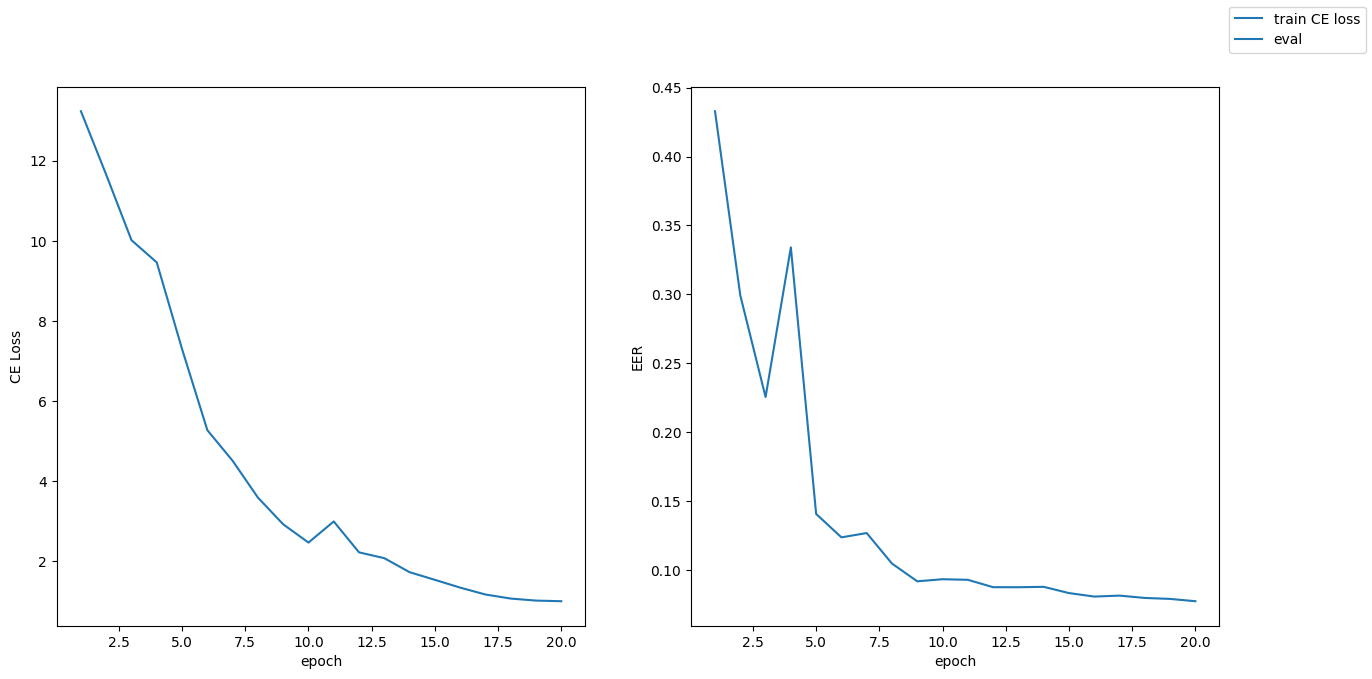

Epoch 20. Train loss 0.996350497569678. Eval score 0.07769088943988811


In [28]:
num_epochs = 20

model = EcapaTDNN(FEATS, trainset.speakers(), 1024, hidden=128, bottle_neck=168).to(DEVICE)
opt = optim.Adam(model.parameters(), weight_decay=2e-5, lr=1e-2)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=1e-3,
    epochs=num_epochs,
    steps_per_epoch=1,
)

train(model, opt, batch_size=128, epochs=num_epochs, train_kwargs = {"scheduler": scheduler})

In [32]:
torch.save(model, '/content/drive/MyDrive/EcapaTDNN.pt')

### Contrastive losses (10 points)

You can use anyone constrative loss.
Good article with contrastive losses https://lilianweng.github.io/posts/2021-05-31-contrastive/

Base losses:
- contrastive
- triplet -- it gives a better quality usually
- lifted structured loss -- better batch data utilization

The main problem with contrastive loss is the positive pairs sampler.
This is because a large number of classes provided only once per batch
in case of large number of classes in the dataset.

In [38]:
# Сохраннённый чекпойнт
!gdown https://drive.google.com/uc?id=12S4KxTeoxQ6hSmDEzOxBQKFPTeSH5yti

Downloading...
From (original): https://drive.google.com/uc?id=12S4KxTeoxQ6hSmDEzOxBQKFPTeSH5yti
From (redirected): https://drive.google.com/uc?id=12S4KxTeoxQ6hSmDEzOxBQKFPTeSH5yti&confirm=t&uuid=cb548f19-6875-4135-8829-f62ffdbfdf27
To: /content/EcapaTDNN.pt
100% 112M/112M [00:00<00:00, 258MB/s]


In [40]:
from collections import defaultdict

class PositivePairsSampler(torch.utils.data.Sampler):
    """
    in my case, batch size is an amount of pairs
    """
    def __init__(self, speakers: list[int], batch_size: int):
        self.speakers = speakers
        self.batch_size = batch_size

        self.speaker_to_index = defaultdict(list)
        for i, elem in enumerate(speakers):
            self.speaker_to_index[elem].append(i)

        self.speakers_set = list(set(speakers))
        self.validate_speakers()

    def validate_speakers(self):
        valid_speakers = []
        for elem in self.speakers_set:
            if len(self.speaker_to_index[elem]) >= 2:
                valid_speakers.append(elem)
        self.speakers_set = valid_speakers

    def __len__(self):
        return (len(self.speakers) - 1) // self.batch_size + 1

    def __iter__(self):
        # yield __len__ batches as list of indexes of samples from dataset
        # <YOUR CODE IS HERE>
        for _ in range(len(self)):
            personas = np.random.choice(self.speakers_set, size=self.batch_size)
            indexes = []
            for persona in personas:
                indexes.extend(np.random.choice(self.speaker_to_index[persona], size=2, replace=False))
            yield indexes

In [ ]:
!pip install pytorch-metric-learning

In [46]:
from pytorch_metric_learning import losses

def contrastive_train_stage(model, opt, loss_func, batch_size: int = 128):
    # You can use any contrastive loss here to improve training
    # You can combine contrastive loss with the NLL loss after AAM softmax to improve stability
    loader = torch_data.DataLoader(
        trainset,
        collate_fn=dataset.collate_fn,
        num_workers=LOADER_WORKERS,
        batch_sampler=PositivePairsSampler(trainset._speakers, batch_size)
    )
    loss_sum = 0.0
    batches = 0
    for x, labels, _ in tqdm.tqdm(loader):
        _, embds = model.forward(x.to(DEVICE))
        loss = loss_func(embds, labels.to(DEVICE))
        loss_sum += loss.item()
        batches += 1
        opt.zero_grad()
        loss.backward()
        opt.step()
    if scheduler is not None:
        scheduler.step()
    return loss_sum / batches

Train model with contrastive loss here. At this point you can archive EER near 0.06-0.07 (it should be at least on 0.005 to 0.01 better than before)

In [47]:
model = torch.load('/content/EcapaTDNN.pt', weights_only=False).to(DEVICE)
opt = optim.Adam(model.parameters(), lr=3e-4)
loss_func = losses.LiftedStructureLoss(neg_margin=1, pos_margin=0)
train(model, opt, batch_size=128, train_fun=contrastive_train_stage, train_kwargs={'loss_func': loss_func})

  0%|          | 0/530 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.28 GiB. GPU 0 has a total capacity of 94.97 GiB of which 131.88 MiB is free. Including non-PyTorch memory, this process has 94.83 GiB memory in use. Of the allocated memory 87.80 GiB is allocated by PyTorch, and 6.37 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)